In [4]:
import pandas as pd
import datetime
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import copy


In [5]:
def CAGR(DF):
    """"Function to calculate the Cumulative Annual Growth Rate of trading strategy"""
    df = DF.copy()
    df["cum_return"]  = (1 + df["mon_ret"]).cumprod()
    n = len(df)/12
    CAGR = (df["cum_return"].iloc[-1]  ** (1/n)) - 1
    return CAGR
def volatility(DF):
    """"Function to calculate annualized volatility of a trading strategy"""
    df=DF.copy()
    vol = df["mon_ret"].std() * np.sqrt(12)
    return vol
def sharpe(DF, rf):
    """"Function to calculate sharpe ratio, rf is the risk free ratio"""
    df = DF.copy()
    sr = (CAGR(df) - rf)/volatility(df)
    return sr
def max_dd(DF):
    """Function to calculate max drawdown"""
    df = DF.copy()
    df["cum_return"] = (1 + df["mon_ret"]).cumprod()
    df["cum_roll_max"]  = df["cum_return"].cummax()
    df["drawdown"] = df["cum_roll_max"] - df["cum_return"]
    df["drawdown_pct"] = df["drawdown"]/df["cum_roll_max"]
    max_dd = df["drawdown_pct"].max()
    return max_dd

tickers = ["MMM","AXP","T","BA","CAT","CSCO","KO", "XOM","GE","GS","HD",
           "IBM","INTC","JNJ","JPM","MCD","MRK","MSFT","NKE","PFE","PG","TRV",
           "UNH","VZ","V","WMT","DIS"]

ohlc_mon = {}
attempt = 0
drop = []
while len(tickers) != 0 and attempt <= 5:
    tickers = [j for j in tickers if j not in drop]
    for i in range(len(tickers)):
        try:
            ohlc_mon[tickers[i]] = yf.download(tickers[i], datetime.date.today() - datetime.timedelta(1900), datetime.date.today(), interval = '1mo')
            ohlc_mon[tickers[i]].dropna(inplace = True)
            drop.append(tickers[i])
        except:  # noqa: E722
            print(tickers[i], " : failed to fetch data... retrying")
            continue
    attempt+=1
tickers = ohlc_mon.keys()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [6]:
ohlc_dict  = copy.deepcopy(ohlc_mon)
return_df = pd.DataFrame()

for ticker in tickers:
    print("calculating monthly return for ", ticker)
    ohlc_dict[ticker]["mon_ret"] = ohlc_dict[ticker]["Close"].pct_change()
    return_df[ticker] = ohlc_dict[ticker]["mon_ret"]

calculating monthly return for  MMM
calculating monthly return for  AXP
calculating monthly return for  T
calculating monthly return for  BA
calculating monthly return for  CAT
calculating monthly return for  CSCO
calculating monthly return for  KO
calculating monthly return for  XOM
calculating monthly return for  GE
calculating monthly return for  GS
calculating monthly return for  HD
calculating monthly return for  IBM
calculating monthly return for  INTC
calculating monthly return for  JNJ
calculating monthly return for  JPM
calculating monthly return for  MCD
calculating monthly return for  MRK
calculating monthly return for  MSFT
calculating monthly return for  NKE
calculating monthly return for  PFE
calculating monthly return for  PG
calculating monthly return for  TRV
calculating monthly return for  UNH
calculating monthly return for  VZ
calculating monthly return for  V
calculating monthly return for  WMT
calculating monthly return for  DIS


In [7]:
def pfolio(DF, m, x):
    """Returns cumulative portfolio return
    DF = dataframe with monthly return info for all stocks
    m = number of stock in the portfolio
    x = number of underperforming stocks to be removed from portfolio monthly
    """
    
    df = DF.copy()
    portfolio = []
    monthly_ret = [0]
    
    for i in range(1, len(df)):
        if len(portfolio) > 0:
            monthly_ret.append(df[portfolio].iloc[i,:].mean())
            bad_stocks = df[portfolio].iloc[i, :].sort_values(ascending=True)[:x].index.values.tolist()
            portfolio = [t for t in portfolio if t not in bad_stocks]
        fill = m - len(portfolio)
        new_picks = df[[t for t in df.columns if t not in portfolio]].iloc[i, :].sort_values(ascending=False)[:fill].index.values.tolist()
        portfolio = portfolio + new_picks
    monthly_ret_df= pd.DataFrame(np.array(monthly_ret),columns=["mon_ret"])
    return monthly_ret_df

In [8]:


print("CAGR :", CAGR(pfolio(return_df, 6, 3)))
print("Max DrawDown :", max_dd(pfolio(return_df, 6, 3)))
print("Sharpe :", sharpe(pfolio(return_df, 6, 3), 0.025))

CAGR : 0.14293656870313698
Max DrawDown : 0.23071875077618378
Sharpe : 0.6525828834872966


In [9]:
DJI = yf.download("^DJI",datetime.date.today()-datetime.timedelta(3650),datetime.date.today(),interval='1mo')
DJI["mon_ret"] = DJI["Close"].pct_change().fillna(0)
CAGR(DJI)
sharpe(DJI,0.025)
max_dd(DJI)


[*********************100%***********************]  1 of 1 completed


0.23201266165063425

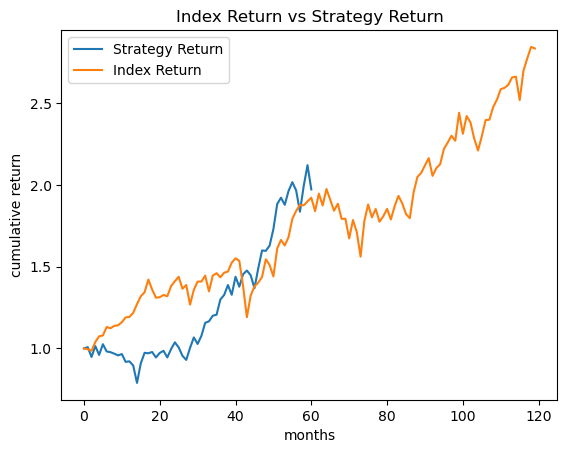

In [10]:
fig, ax = plt.subplots()
plt.plot((1+pfolio(return_df,6,3)).cumprod())
plt.plot((1+DJI["mon_ret"].reset_index(drop=True)).cumprod())
plt.title("Index Return vs Strategy Return")
plt.ylabel("cumulative return")
plt.xlabel("months")
ax.legend(["Strategy Return","Index Return"])